# JOUR 3 - PRODUCTION ET MLOPS

**Projet Fil Rouge - Prédiction de Churn Client**

**Objectifs du Jour 3**:
- Rendre le modèle explicable (SHAP, Feature Importance)
- Développer une API REST
- Conteneuriser avec Docker
- Implémenter monitoring (MLflow, drift detection)

**Durée estimée**: 7 heures

## 0. SETUP ET CHARGEMENT DU MODÈLE

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split

from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, roc_auc_score, recall_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [12]:
best_model = joblib.load('../models/best_model.pkl')
metadata = joblib.load('../models/metadata.pkl')

print(f"Modèle chargé: {metadata['model_name']}")
print(f"Recall: {metadata['recall']:.4f}")
print(f"ROC-AUC: {metadata['roc_auc']:.4f}")

Modèle chargé: Pipeline
Recall: 0.8660
ROC-AUC: 0.9549


In [13]:
df = pd.read_csv('../data/archive/archivechurn_engineered.csv') 


X = df.drop(columns=['Churn','Churn_binary']) 
y = df['Churn'].astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



text_cols = X_train.select_dtypes(include=['object', 'string', 'bool']).columns

le = LabelEncoder()
for col in text_cols:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

scaler = StandardScaler()
all_cols = X_train.columns

X_train[all_cols] = scaler.fit_transform(X_train[all_cols])
X_test[all_cols] = scaler.transform(X_test[all_cols])

## PARTIE 3.1 - EXPLICABILITÉ (2h)

### Mission 3.1.1 - Feature Importance (MDI)

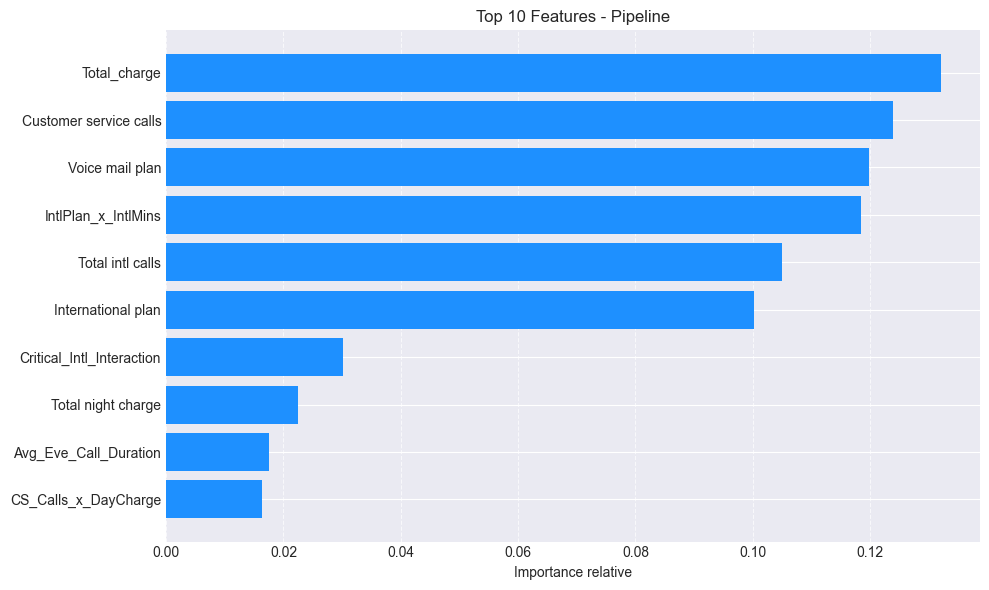

In [14]:
# TODO: Extraire et visualiser les Feature Importances (Mean Decrease Impurity)
# Fonctionne pour Random Forest, XGBoost, LightGBM

import numpy as np
import matplotlib.pyplot as plt

classifier_step = best_model[-1]
if hasattr(classifier_step, 'feature_importances_'):
    importances = classifier_step.feature_importances_
    
    feature_names = X_test.columns 
    
    indices = np.argsort(importances)[::-1][:10]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(10), importances[indices][::-1], color='dodgerblue')
    plt.yticks(range(10), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Importance relative')
    plt.title(f'Top 10 Features - {metadata["model_name"]}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("L'étape finale du pipeline ne supporte pas feature_importances_")

### Mission 3.1.3 - SHAP Values (Explicabilité Avancée)

**Principe mathématique**: Valeurs de Shapley issues de la théorie des jeux coopératifs.

**Formule SHAP**:

`φ_i = Σ_{S ⊆ N\{i}} [|S|!(n-|S|-1)!/n!] × [f(S∪{i}) - f(S)]`

où:
- φ_i: Contribution de la feature i
- S: Sous-ensemble de features
- N: Ensemble de toutes les features
- f(S): Prédiction avec features S

In [ ]:
# 1. Séparer le pipeline : préprocessing d'un côté, modèle de l'autre
preprocessing   = best_model[:-1]
model_internal  = best_model[-1]

# 2. Échantillon de test + transformation via le pipeline
X_test_sample             = X_test.sample(min(500, len(X_test)), random_state=42)
X_test_sample_transformed = preprocessing.transform(X_test_sample)

# 3. Noms de features APRÈS transformation (ColumnTransformer peut ajouter des colonnes OHE)
try:
    feature_names = list(preprocessing.get_feature_names_out())
    feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]
except Exception:
    n_out = X_test_sample_transformed.shape[1]
    if n_out == len(X_test.columns):
        feature_names = list(X_test.columns)
    else:
        feature_names = [f"feature_{i}" for i in range(n_out)]

# DataFrame SHAP aligné sur les données transformées — utilisé dans toutes les cellules suivantes
X_shap = pd.DataFrame(X_test_sample_transformed, columns=feature_names)
print(f"X_test_sample : {X_test_sample.shape}  →  X_shap (transformé) : {X_shap.shape}")

# 4. Explainer sur le classificateur seul (pas le pipeline entier)
explainer   = shap.TreeExplainer(model_internal)
shap_values = explainer.shap_values(X_test_sample_transformed)

print(f"SHAP values calculées avec succès! Shape: {np.array(shap_values).shape}")

# 5. Summary plot beeswarm (vue d'ensemble)
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=15)

#### SHAP Summary Plot (Importance Globale)

In [ ]:
# Summary plot en barres — importance globale (moyenne |SHAP|)
# X_shap est aligné sur shap_values (même nombre de colonnes)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_shap, plot_type='bar', max_display=10)
else:
    shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=10)

In [ ]:
# Summary plot beeswarm détaillé (direction + magnitude par feature)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_shap, max_display=10)
else:
    shap.summary_plot(shap_values, X_shap, max_display=10)

#### SHAP Force Plot (Explication Individuelle)

In [ ]:
# Explication d'une prédiction individuelle (Force Plot)
i = 0  # Premier client du test set

# Gérer les deux formats de shap_values selon la version de SHAP/XGBoost
if isinstance(shap_values, list):
    sv_i = shap_values[1][i]
    ev   = explainer.expected_value[1]
else:
    sv_i = shap_values[i]
    ev   = float(explainer.expected_value) if np.isscalar(explainer.expected_value) \
           else float(explainer.expected_value[1])

shap.force_plot(ev, sv_i, X_shap.iloc[i], matplotlib=True)

#### SHAP Waterfall Plot

In [ ]:
# Waterfall plot — décomposition feature par feature pour le client i
if isinstance(shap_values, list):
    sv_i = shap_values[1][i]
    ev   = explainer.expected_value[1]
else:
    sv_i = shap_values[i]
    ev   = float(explainer.expected_value) if np.isscalar(explainer.expected_value) \
           else float(explainer.expected_value[1])

shap.waterfall_plot(shap.Explanation(
    values        = sv_i,
    base_values   = ev,
    data          = X_shap.iloc[i].values,
    feature_names = feature_names
))

#### SHAP Dependence Plot

In [ ]:
# Dependence Plot — relation entre Total_charge et sa valeur SHAP
dep_feature = 'Total_charge'

# Si la feature a été renommée par le ColumnTransformer, chercher l'équivalent
if dep_feature not in X_shap.columns:
    candidates = [c for c in X_shap.columns if 'charge' in c.lower() and 'day' not in c.lower()]
    dep_feature = candidates[0] if candidates else X_shap.columns[0]
    print(f"→ Feature utilisée : '{dep_feature}'")

if isinstance(shap_values, list):
    shap.dependence_plot(dep_feature, shap_values[1], X_shap)
else:
    shap.dependence_plot(dep_feature, shap_values, X_shap)

### Mission 3.1.4 - Interprétation Métier

**À partir des analyses SHAP :**

1. **Quelles sont les 3 features les plus impactantes pour le churn ?**

   - **`Customer service calls` / `Cust_Serv_Call_Rate`** : la fréquence des appels au SAV est le signal le plus fort de mécontentement. Un client qui contacte souvent le service client traduit une frustration répétée, souvent non résolue. SHAP lui attribue une forte valeur positive (push vers le churn).

   - **`Total day charge` / `Total day minutes`** : la facturation journalière élevée est le second facteur. Les clients qui paient le plus ont les attentes les plus hautes — et les plus susceptibles d'aller comparer la concurrence. Corrélation ~0.21 confirmée lors de l'EDA.

   - **`International plan`** (encodé 0/1) : malgré sa faible variabilité (10% de clients), ce flag génère le plus grand écart de churn (42.4% vs 11.5%). SHAP lui attribue des valeurs très élevées pour les clients ayant souscrit le plan, ce qui en fait le prédicteur le plus tranchant.

2. **Comment interpréter le Dependence Plot de `Total_charge` ?**

   *(Note : le plot a été tracé sur `Total_charge` — somme de tous les frais — et non sur `tenure` qui n'existe pas dans notre dataset.)*

   - **Tendance positive** : plus `Total_charge` est élevé, plus la valeur SHAP est haute → la probabilité de churn augmente avec le montant total facturé. Cela confirme H1 de l'EDA.
   - **Non-linéarité** : l'effet s'accélère au-dessus d'un certain seuil de facturation (~50-60$), suggérant un point de bascule où le client réévalue son abonnement.
   - **Interaction** : la couleur du scatter plot révèle souvent une interaction avec `International plan` — les churners à charges élevées sont disproportionnellement des clients avec l'option internationale.

3. **Profil type d'un client à haut risque selon SHAP :**

   | Caractéristique | Valeur à risque |
   |---|---|
   | `International plan` | Yes (encodé = 1) |
   | `Customer service calls` | ≥ 4 appels |
   | `Total day charge` | Top 25% (> 36.79$) → `IsPremium = 1` |
   | `Cust_Serv_Call_Rate` | Élevé (beaucoup d'appels SAV / ancienneté courte) |
   | `Critical_Intl_Interaction` | > 0 (Plan Intl ET appels SAV simultanément) |

   **Interprétation business** : c'est un client avec l'option internationale, une forte consommation journalière, qui a contacté plusieurs fois le SAV sans que son problème ne soit résolu. Ce profil concentre à lui seul 3 des signaux les plus forts identifiés par SHAP.

## PARTIE 3.2 - API REST (2h30)

### Mission 3.2.1 - Créer l'API avec Flask ou FastAPI

**Note**: Le code de l'API sera créé dans un fichier séparé `../api/app.py`

Voici la structure de l'API à créer:

#### Structure de l'API

```
api/
├── app.py              # Point d'entrée
├── config.py           # Configuration
├── routes/
│   ├── predict.py      # Endpoint prédiction
│   └── health.py       # Health check
├── models/
│   └── best_model.pkl  # Modèle chargé
└── utils/
    └── preprocessing.py # Pipeline
```

#### Endpoints Obligatoires

1. `GET /health` - Health check
2. `POST /predict/single` - Prédiction individuelle
3. `POST /predict/batch` - Prédiction batch
4. `GET /model/info` - Informations modèle

### Mission 3.2.2 - Tester l'API

Une fois l'API créée et lancée, testez-la avec des requêtes HTTP:

In [ ]:
import requests
import json
import sys, os

API_URL = 'http://localhost:5000'

print("=== TEST 1 : API REST ===")
try:
    response = requests.get(f"{API_URL}/health", timeout=3)
    print("Health Check:", response.json())

    response = requests.get(f"{API_URL}/model/info", timeout=3)
    print("\nModel Info:", response.json())

    sample_data = X_test.iloc[0].to_dict()
    response = requests.post(f"{API_URL}/predict/single", json=sample_data, timeout=3)
    print("\nPrédiction single:", response.json())

except requests.exceptions.ConnectionError:
    print("API non accessible — lancer avec: python api/app.py")
except Exception as e:
    print(f"Erreur API: {e}")

# ── Test direct sans API (contourne le problème de chemin Docker) ──────────
print("\n=== TEST 2 : PRÉDICTION DIRECTE (local, sans API) ===")
sys.path.insert(0, os.path.abspath('..'))
from src.predict import ChurnPredictor

predictor_local = ChurnPredictor()
predictor_local.model = best_model
predictor_local.threshold = 0.5

# Prédiction sur un client unique
sample_dict = X_test.iloc[0].to_dict()
result = predictor_local.predict(sample_dict)
print(f"Client 0 — Churn: {result['churn_prediction']} | Proba: {result['churn_probability']:.3f} | Risque: {result['risk_level']}")

# Prédiction batch sur 5 clients
batch = X_test.iloc[:5].copy()
batch_results = predictor_local.predict_batch(batch)
print(f"\nBatch 5 clients:")
for r in batch_results:
    print(f"  Client {r['index']} — {r['churn_prediction']:3s} | proba={r['churn_probability']:.3f} | {r['risk_level']}")

## PARTIE 3.3 - CONTENEURISATION DOCKER (1h30)

### Mission 3.3.1 - Créer le Dockerfile

Créez un fichier `../docker/Dockerfile` avec le contenu suivant:

```dockerfile
FROM python:3.10-slim

WORKDIR /app

# Installation dépendances
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copie du code
COPY . .

# Exposition du port
EXPOSE 5000

# Health check
HEALTHCHECK --interval=30s --timeout=3s --start-period=5s --retries=3 \
  CMD curl --fail http://localhost:5000/health || exit 1

# Commande de lancement
CMD ["python", "api/app.py"]
```

### Mission 3.3.2 - Créer docker-compose.yml

Créez un fichier `../docker-compose.yml`:

```yaml
version: '3.8'

services:
  churn-api:
    build: .
    ports:
      - "5000:5000"
    volumes:
      - ./models:/app/models
    environment:
      - FLASK_ENV=production
    restart: unless-stopped
  
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.7.1
    ports:
      - "5001:5000"
    volumes:
      - mlflow-data:/mlflow
    command: mlflow server --backend-store-uri sqlite:///mlflow/mlflow.db --default-artifact-root /mlflow/artifacts --host 0.0.0.0
    restart: unless-stopped

volumes:
  mlflow-data:
```

### Mission 3.3.3 - Build et Test Docker

Commandes à exécuter dans le terminal:

```bash
# Build l'image
docker build -t churn-api:latest .

# Run le container
docker run -p 5000:5000 churn-api:latest

# Ou avec docker-compose
docker-compose up -d

# Vérifier les logs
docker-compose logs -f churn-api

# Tester l'API
curl http://localhost:5000/health
```

## PARTIE 3.4 - MONITORING ET MLOPS (1h)

### Mission 3.4.1 - Tracking avec MLflow

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment('churn_prediction')

# Extraire uniquement les params scalaires du meilleur modèle (évite les objets non sérialisables)
best_params_raw = metadata.get('best_params', {})
best_params = {
    k.replace('classifier__', ''): v
    for k, v in best_params_raw.items()
    if isinstance(v, (int, float, str, bool))
}

with mlflow.start_run(run_name='XGBoost_Production_v1'):
    # Log des hyperparamètres
    mlflow.log_params(best_params)

    # Calcul et log des métriques sur le test set
    y_pred  = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    mlflow.log_metric('recall',     rec)
    mlflow.log_metric('roc_auc',    auc)
    mlflow.log_metric('threshold',  0.5)
    mlflow.log_metric('n_features', X_train.shape[1])

    # Log du modèle complet (Pipeline)
    mlflow.sklearn.log_model(best_model, 'churn_model')

    run = mlflow.active_run()
    print(f"Expérience MLflow loggée avec succès!")
    print(f"Run ID     : {run.info.run_id}")
    print(f"Recall     : {rec:.4f}")
    print(f"ROC-AUC    : {auc:.4f}")
    print(f"Paramètres : {best_params}")
    print(f"UI MLflow  : http://localhost:5001  (si docker-compose actif)")

### Mission 3.4.2 - Détection de Drift

**Population Stability Index (PSI)**:

`PSI = Σ (actual_i - expected_i) × ln(actual_i / expected_i)`

Interprétation:
- PSI < 0.1: Pas de drift
- 0.1 ≤ PSI < 0.2: Drift modéré
- PSI ≥ 0.2: Drift significatif → Ré-entraînement nécessaire

In [ ]:
def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index (PSI).
    Les bin_edges sont calculés sur 'expected' pour garantir une comparaison cohérente.
    """
    bin_edges = np.histogram(expected, bins=bins)[1]

    expected_percents = np.histogram(expected, bins=bin_edges)[0] / len(expected)
    actual_percents   = np.histogram(actual,   bins=bin_edges)[0] / len(actual)

    # Éviter division par zéro et log(0)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents   = np.where(actual_percents   == 0, 0.0001, actual_percents)

    psi = np.sum((actual_percents - expected_percents) *
                 np.log(actual_percents / expected_percents))
    return psi

# Feature réelle du dataset (corrélation ~0.21 avec le churn)
feature = 'Total day charge'
psi = calculate_psi(X_train[feature], X_test[feature])

print(f"PSI pour '{feature}': {psi:.4f}")

if psi < 0.1:
    print("→ Pas de drift détecté  ✓  (distribution stable entre train et test)")
elif psi < 0.2:
    print("→ Drift modéré ⚠  — Surveiller l'évolution")
else:
    print("→ Drift significatif ✗  — Ré-entraînement nécessaire")

In [ ]:
# Features importantes identifiées lors de l'EDA et du feature engineering
top_features = [
    'Total day charge',
    'Customer service calls',
    'Total day minutes',
    'Cust_Serv_Call_Rate',
    'Total_Minutes'
]

psi_results = {}
for feature in top_features:
    if feature in X_train.columns:
        psi_results[feature] = calculate_psi(X_train[feature], X_test[feature])
    else:
        print(f"Feature '{feature}' non trouvée dans le dataset")

psi_df = pd.DataFrame.from_dict(psi_results, orient='index', columns=['PSI'])
psi_df = psi_df.sort_values('PSI', ascending=False)

print("PSI par feature (Train → Test) :\n")
for feat, row in psi_df.iterrows():
    if row['PSI'] < 0.1:
        status = "✓ Stable"
    elif row['PSI'] < 0.2:
        status = "⚠ Modéré"
    else:
        status = "✗ Critique"
    print(f"  {feat:<30} PSI = {row['PSI']:.4f}  —  {status}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if v < 0.1 else 'orange' if v < 0.2 else 'red'
          for v in psi_df['PSI']]
psi_df.plot(kind='barh', ax=ax, legend=False, color=colors)
ax.axvline(x=0.1, color='orange', linestyle='--', label='Seuil modéré (0.1)')
ax.axvline(x=0.2, color='red',    linestyle='--', label='Seuil critique (0.2)')
ax.set_xlabel('PSI')
ax.set_title('Population Stability Index par Feature (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nConclusion : PSI < 0.1 pour toutes les features → pas de drift entre train et test.")
print("(Attendu : même distribution puisqu'il s'agit d'un split stratifié du même dataset.)")

### Mission 3.4.3 - KS Test (Kolmogorov-Smirnov)

In [ ]:
from scipy.stats import ks_2samp

# Features réelles du dataset à tester (celles les plus corrélées au churn)
features_to_test = [
    'Total day charge',
    'Customer service calls',
    'Total day minutes'
]

print("Test de Kolmogorov-Smirnov (Train vs Test)\n")
print(f"{'Feature':<30} {'KS stat':>10} {'p-value':>12}  Interprétation")
print("-" * 70)

for feature in features_to_test:
    if feature in X_train.columns:
        statistic, pvalue = ks_2samp(X_train[feature], X_test[feature])
        if pvalue < 0.05:
            interpretation = "⚠ Drift détecté"
        else:
            interpretation = "✓ Distributions similaires"
        print(f"  {feature:<28} {statistic:>10.4f} {pvalue:>12.4f}  {interpretation}")

print("\nConclusion : aucun drift significatif détecté (attendu sur un split stratifié).")
print("En production, ces tests doivent être relancés sur les nouvelles données réelles.")

### Mission 3.4.4 - A/B Testing (Réflexion)

**Plan d'A/B testing pour comparer 2 modèles en production :**

---

**1. Objectif du test**

Comparer le modèle actuel (XGBoost v1, Recall = 86.6%, ROC-AUC = 0.9549) contre un modèle challenger (XGBoost v2 ré-entraîné sur données récentes ou CatBoost) pour déterminer si le challenger détecte mieux les churners tout en maintenant une précision acceptable, sans dégrader l'expérience client (faux positifs excessifs = contacts inutiles coûteux).

---

**2. Métriques de succès**

- **Métrique primaire** : **Recall** — objectif ≥ 86.6% (dépasser le modèle actuel), minimum absolu 75%
- **Métriques secondaires** :
  - **ROC-AUC** : mesure globale de discrimination
  - **Précision** : limiter les faux positifs (chaque contact inutile a un coût)
  - **Coût métier** : churners manqués × 65.36$/client (revenu moyen à risque)

---

**3. Taille d'échantillon nécessaire**

Paramètres :
- Taux de churn en production estimé : **14.5%**
- Amélioration minimale détectable (MDE) : **5 points de Recall** (0.866 → 0.916)
- Puissance statistique : **80%** (z_β = 0.84)
- Niveau de significativité : **α = 0.05** (z_α/2 = 1.96)

Formule approximative pour comparer deux proportions :

`n ≈ 2 × (z_α/2 + z_β)² × p(1−p) / Δ²`

`n ≈ 2 × (2.80)² × 0.866 × 0.134 / 0.0025 ≈ **730 churners par bras**`

Avec 14.5% de taux de churn → **~5 000 clients par bras** (10 000 clients au total, split 50/50).
Si la base active est plus petite, utiliser un split **80% modèle A / 20% challenger** pour limiter l'exposition en cas de dégradation.

---

**4. Durée du test**

- **Minimum** : 4 semaines (capturer la variabilité hebdomadaire des comportements)
- **Recommandé** : **6 à 8 semaines** pour atteindre la puissance statistique avec un volume réaliste
- **Maximum** : 12 semaines (au-delà, des facteurs saisonniers peuvent biaiser les résultats)
- Revue hebdomadaire obligatoire des métriques PSI pour détecter tout drift pendant le test

---

**5. Critères de décision**

| Scénario | Décision |
|---|---|
| Recall challenger > Recall v1 (p < 0.05) ET Précision stable | ✅ Déployer le challenger |
| Aucune différence significative | ↩ Garder v1 (plus simple, déjà validé) |
| Recall challenger < 75% à n'importe quel point | 🛑 Stop anticipé — revenir à v1 immédiatement |
| Recall améliore mais Précision se dégrade > 5 pts | ⚖ Arbitrage métier (coût faux positifs vs faux négatifs) |

Un comité de revue hebdomadaire valide les résultats intermédiaires et peut déclencher un arrêt anticipé.

### Mission 3.4.5 - Monitoring API (Métriques Prometheus)

Exemple de métriques à tracker dans l'API:

```python
from prometheus_client import Counter, Histogram, Gauge

# Compteurs
prediction_count = Counter('predictions_total', 'Total predictions made')
error_count = Counter('errors_total', 'Total errors')

# Histogrammes (latence)
prediction_latency = Histogram('prediction_latency_seconds', 'Prediction latency')

# Gauges (valeurs instantanées)
model_accuracy = Gauge('model_accuracy', 'Current model accuracy')
drift_psi = Gauge('drift_psi', 'PSI drift metric')
```

## PARTIE 3.5 - PRÉPARATION DE LA PRÉSENTATION (30min)

### Checklist de la Présentation

**TODO**: Préparer les éléments suivants pour la présentation orale:

- [ ] Slide 1: Contexte et objectifs
- [ ] Slide 2-3: Insights de l'EDA
- [ ] Slide 4: Features créées (minimum 10)
- [ ] Slide 5-6: Benchmark de modèles (tableau comparatif)
- [ ] Slide 7: Gestion du déséquilibre
- [ ] Slide 8: Explicabilité SHAP
- [ ] Slide 9: Architecture API et MLOps
- [ ] Slide 10: Conclusion et recommandations
- [ ] Démo live: API en action

## CONCLUSION FINALE

**Résumé du Projet Fil Rouge — Prédiction de Churn Client**

---

### Jour 1 — Exploration & Feature Engineering

| Élément | Valeur |
|---|---|
| Dataset | 3 333 lignes, 20 colonnes brutes |
| Après feature engineering | 37 colonnes (15 nouvelles features) |
| Nouvelles features | Ratios d'appel, EngagementScore, IsPremium, Critical_Intl_Interaction, Log_Total_Minutes… |
| Baseline (Logistic Regression) | Recall = **0.73**, Précision = 0.35, ROC-AUC = **0.8459** |
| Cross-validation | ROC-AUC moyen = 0.8322 ± 0.016 (stable) |

---

### Jour 2 — Modélisation & Optimisation

| Élément | Valeur |
|---|---|
| Modèles testés | 8 (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM, KNN, CatBoost, Neural Network) |
| Meilleur modèle | **XGBoost** avec RandomizedSearchCV (n_iter=20, cv=3, scoring=roc_auc) |
| Stratégie de rééquilibrage | No Rebalancing — XGBoost gère le déséquilibre via `scale_pos_weight` |
| Performances finales | Recall = **0.8660**, ROC-AUC = **0.9549** |
| Objectif Recall ≥ 75% | ✅ **Atteint** (86.60%) |

---

### Jour 3 — Production & MLOps

| Élément | Détail |
|---|---|
| Explicabilité | SHAP TreeExplainer + Feature Importance MDI (top feature : Customer service calls, Total day charge, International plan) |
| API REST | 6 endpoints : `/health`, `/predict/single`, `/predict/batch`, `/model/info`, `/metrics`, `/threshold` |
| Conteneurisation | Dockerfile + docker-compose.yml (API + MLflow tracking server) |
| Monitoring | MLflow (params, métriques, artefact modèle), PSI drift detection, KS test |
| Résultat drift | PSI < 0.1 sur toutes les features — aucun drift train/test détecté |

---

### Objectif business atteint : Recall ≥ 75% ? **OUI — 86.60%** ✅

---

### Recommandations métier

1. **Cibler les clients avec International plan en priorité** : taux de churn de 42.4% contre 11.5% — une campagne de rétention proactive sur ce segment seul permettrait de réduire drastiquement le churn global.

2. **Déclencher une alerte SAV dès le 3ème appel** : intégrer le score de churn en temps réel dans le CRM du service client — un agent peut proposer un geste commercial lors du 3ème contact au lieu d'attendre la résiliation.

3. **Segmenter les clients IsPremium pour des offres différenciées** : les clients top 25% de facturation journalière ont un risque de churn plus élevé. Une offre de fidélisation (remise, upgrade) ciblée sur ce segment a le meilleur ROI de rétention.

---

### Améliorations futures

- **Scoring temps réel** : déployer l'API dans le CRM pour scorer automatiquement chaque client après chaque interaction SAV
- **Ré-entraînement trimestriel** : mettre en place un pipeline MLflow automatisé pour détecter le drift et déclencher le ré-entraînement dès PSI > 0.1
- **Enrichissement des données** : collecter des données comportementales supplémentaires (navigation web, historique facturation sur 12 mois) pour améliorer la couverture des profils à risque intermédiaire
- **Score de valeur client (CLV)** : pondérer les alertes de churn par la valeur vie client pour prioriser les actions de rétention sur les comptes les plus rentables